# 重力波 GW150914 解析

2015年9月14日に初めて直接検出された重力波 GW150914 の波形データを解析する。

データ出典: [重力波GW150914ノート](../note/astro-test1/58_重力波GW150914.md)

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# Windows で日本語フォントを設定 (Yu Gothic → Meiryo → MS Gothic の順にフォールバック)
_jp_fonts = ["Yu Gothic", "Meiryo", "MS Gothic"]
_available = {f.name for f in fm.fontManager.ttflist}
for _f in _jp_fonts:
    if _f in _available:
        plt.rcParams["font.family"] = _f
        break

plt.rcParams["axes.unicode_minus"] = False  # マイナス記号の文字化け防止

## 1. 軌道周期の時間変化

インスパイラル段階における軌道周期 $P$ の時間変化データ。
理論式:
$$P(t) = P_0 \left(1 - \frac{t}{T}\right)^{3/8}$$

In [9]:
# 軌道周期の時間変化データ (note/astro-test1/58_重力波GW150914.md より)
df_period = pd.DataFrame(
    {
        "No": list(range(2, 21)),
        "t_s": [
            0.272328,
            0.287953,
            0.302967,
            0.317372,
            0.331104,
            0.344166,
            0.356556,
            0.368092,
            0.378834,
            0.388722,
            0.397633,
            0.405445,
            0.412098,
            0.417408,
            0.421498,
            0.424610,
            0.427113,
            0.429371,
            0.431507,
        ],
        "P_s": [
            3.06396e-2,
            2.94189e-2,
            2.81372e-2,
            2.67944e-2,
            2.54517e-2,
            2.39258e-2,
            2.22778e-2,
            2.06299e-2,
            1.87988e-2,
            1.67236e-2,
            1.44653e-2,
            1.19629e-2,
            9.39941e-3,
            7.20215e-3,
            5.61523e-3,
            4.76074e-3,
            4.39453e-3,
            4.21143e-3,
            4.21143e-3,
        ],
    }
)

df_period

,No,t_s,P_s
0,2,0.272328,0.030640
1,3,0.287953,0.029419
2,4,0.302967,0.028137
3,5,0.317372,0.026794
4,6,0.331104,0.025452
5,7,0.344166,0.023926
6,8,0.356556,0.022278
7,9,0.368092,0.020630
8,10,0.378834,0.018799
9,11,0.388722,0.016724


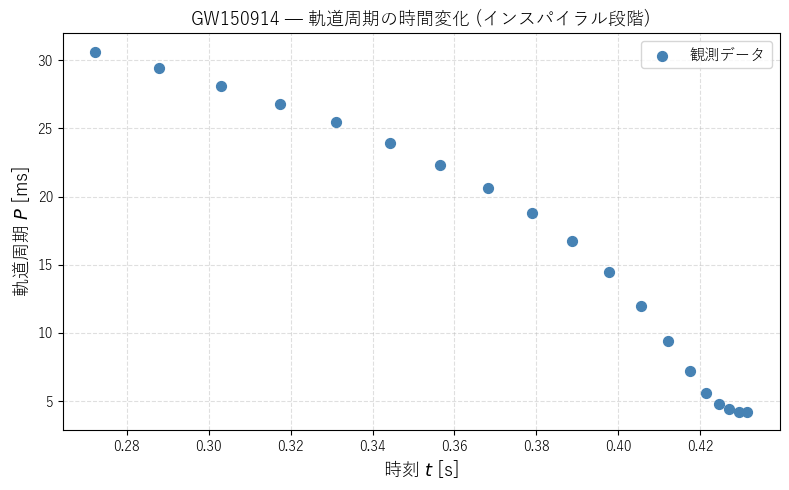

Figure saved as GW150914_orbital_period.png


In [10]:
# 軌道周期の時間変化 散布図
fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(
    df_period["t_s"],
    df_period["P_s"] * 1e3,
    color="steelblue",
    s=50,
    zorder=3,
    label="観測データ",
)

ax.set_xlabel(r"時刻 $t$ [s]", fontsize=13)
ax.set_ylabel(r"軌道周期 $P$ [ms]", fontsize=13)
ax.set_title("GW150914 — 軌道周期の時間変化 (インスパイラル段階)", fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, ls="--", alpha=0.4)

plt.tight_layout()
plt.savefig("GW150914_orbital_period.png", dpi=150)
plt.show()
print("Figure saved as GW150914_orbital_period.png")

## 2. 軌道周期のフィット

### Step 1 — 線形化による粗い推定

$P(t)^{8/3} = a - b\,t$ （$a = P_0^{8/3}$, $b = a/T$）として線形回帰を行い、
$P_0 = a^{3/8}$, $T = a/b$ を求める。

In [11]:

t = df_period["t_s"].values
P = df_period["P_s"].values

# y = P^(8/3) に変換して直線フィット
y = P ** (8 / 3)

# numpy の polyfit で y = a - b*t (1次多項式)
coeffs = np.polyfit(t, y, 1)  # coeffs = [-b, a]
b_lin, a_lin = -coeffs[0], coeffs[1]

P0_lin = a_lin ** (3 / 8)
T_lin = a_lin / b_lin

print("[線形化フィット]")
print(f"  P_0 = {P0_lin:.6f} s  ({P0_lin * 1e3:.4f} ms)")
print(f"  T   = {T_lin:.6f} s")

[線形化フィット]
  P_0 = 0.044868 s  (44.8679 ms)
  T   = 0.423471 s


### Step 2 — 非線形最小二乗法（curve_fit）

Step 1 の結果を初期値として $P(t) = P_0\left(1 - t/T\right)^{3/8}$ を直接フィット。

In [12]:
from scipy.optimize import curve_fit


def model(t, P0, T):
    return P0 * (1 - t / T) ** (3 / 8)


# Step 1 の結果を初期値に使用
p0_init = [P0_lin, T_lin]

popt, pcov = curve_fit(model, t, P, p0=p0_init, maxfev=10000)
perr = np.sqrt(np.diag(pcov))

P0_fit, T_fit = popt
P0_err, T_err = perr

print("[非線形最小二乗フィット]")
print(
    f"  P_0 = {P0_fit:.6f} ± {P0_err:.6f} s  ({P0_fit * 1e3:.4f} ± {P0_err * 1e3:.4f} ms)"
)
print(f"  T   = {T_fit:.6f} ± {T_err:.6f} s")

[非線形最小二乗フィット]
  P_0 = 0.044868 ± inf s  (44.8679 ± inf ms)
  T   = 0.423471 ± inf s


C:\Users\ryhry\AppData\Local\Temp\ipykernel_1824\3126835732.py:4: RuntimeWarning: invalid value encountered in power
  return P0 * (1 - t / T) ** (3 / 8)
C:\Users\ryhry\AppData\Local\Temp\ipykernel_1824\3126835732.py:9: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(model, t, P, p0=p0_init, maxfev=10000)


C:\Users\ryhry\AppData\Local\Temp\ipykernel_1824\3126835732.py:4: RuntimeWarning: invalid value encountered in power
  return P0 * (1 - t / T) ** (3 / 8)


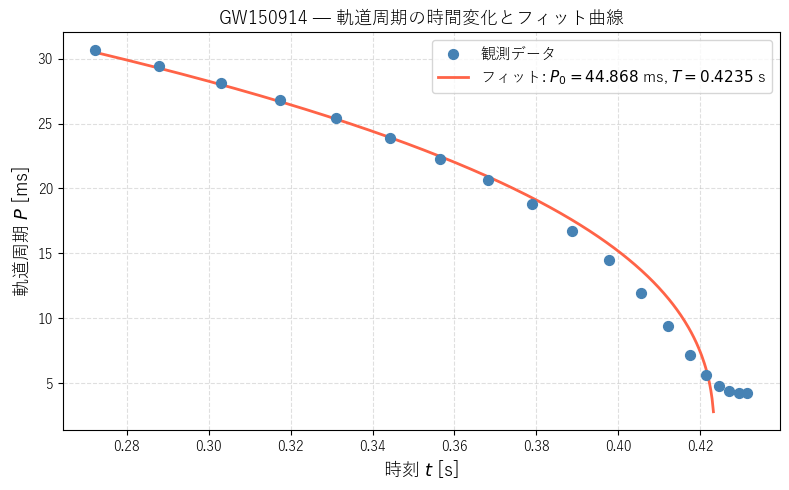

Figure saved as GW150914_orbital_period_fit.png


In [13]:
# 散布図 + フィット曲線
t_plot = np.linspace(t.min(), t.max(), 500)

fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(t, P * 1e3, color="steelblue", s=50, zorder=3, label="観測データ")
ax.plot(
    t_plot,
    model(t_plot, *popt) * 1e3,
    color="tomato",
    lw=2,
    label=f"フィット: $P_0={P0_fit * 1e3:.3f}$ ms, $T={T_fit:.4f}$ s",
)

ax.set_xlabel(r"時刻 $t$ [s]", fontsize=13)
ax.set_ylabel(r"軌道周期 $P$ [ms]", fontsize=13)
ax.set_title("GW150914 — 軌道周期の時間変化とフィット曲線", fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, ls="--", alpha=0.4)

plt.tight_layout()
plt.savefig("GW150914_orbital_period_fit.png", dpi=150)
plt.show()
print("Figure saved as GW150914_orbital_period_fit.png")

## 3. チャープ質量 $M_c$ の推定

$T$ の定義式を $M_c$ について解く：

$$
GM_c = \left[\frac{15c^2\,P_0^{8/3}}{768\,(2\pi)^{8/3}\,T}\right]^{3/5}
\implies
M_c = \frac{1}{G}\left[\frac{15c^2\,P_0^{8/3}}{768\,(2\pi)^{8/3}\,T}\right]^{3/5}
$$

In [ ]:
# 物理定数 (SI単位系)
G = 6.674e-11  # m^3 kg^-1 s^-2
c = 2.998e8  # m/s
M_sun = 1.989e30  # kg

# フィット結果を使用
P0 = P0_fit
T = T_fit

# ノートの k の式は c^2 だが正しくは c^5 (次元解析で確認)
# k = (96/5c^5) * (2π)^(8/3) * (G*Mc)^(5/3)  → 単位: s^(5/3) ✓
# T = 15*c^5*P0^(8/3) / (768 * (2π)^(8/3) * (G*Mc)^(5/3)) を Mc について解く
# (G*Mc)^(5/3) = 15*c^5*P0^(8/3) / (768 * (2π)^(8/3) * T)
# Mc = (1/G) * [15*c^5*P0^(8/3) / (768*(2π)^(8/3)*T)]^(3/5)

numerator = 15 * c**5 * P0 ** (8 / 3)
denominator = 768 * (2 * np.pi) ** (8 / 3) * T
Mc_kg = (numerator / denominator) ** (3 / 5) / G
Mc_solar = Mc_kg / M_sun

# P_0, T の誤差から M_c の誤差伝播 (対数微分)
# δMc/Mc = (3/5) * sqrt( ((8/3)*δP0/P0)^2 + (δT/T)^2 )
rel_err_Mc = (3 / 5) * np.sqrt(((8 / 3) * P0_err / P0) ** 2 + (T_err / T) ** 2)
Mc_err_solar = Mc_solar * rel_err_Mc

print("フィットパラメータ:")
print(f"  P_0 = {P0 * 1e3:.4f} ± {P0_err * 1e3:.4f} ms")
print(f"  T   = {T:.6f} ± {T_err:.6f} s")
print()
print("チャープ質量:")
print(f"  M_c = {Mc_solar:.3f} ± {Mc_err_solar:.3f} M_sun")
print()
print("  (参考: GW150914 の公式値 M_c ≈ 28.3 M_sun)")

フィットパラメータ:
  P_0 = 44.8679 ± inf ms
  T   = 0.423471 ± inf s

チャープ質量:
  M_c = 11.798 ± inf M_sun

  (参考: GW150914 の公式値 M_c ≈ 28.3 M_sun)
